# Biobased Construction Materials Impact Calculator

**Project:** Biobased Construction Impact Calculator
**Database:** `materials_impact_calculator`
**Ecoinvent version:** 3.12, cut-off system model
**Date:** 2026

## Purpose

This notebook is the computational backbone of the materials impact calculator — the
first module of a larger tool for digitally fabricated circular biobased construction
products. It builds the Brightway project, computes recipe-independent unit environmental
burdens and benefits for a list of candidate materials, and provides an interactive
model where a user selects materials, quantities, allocation type, and expected product
lifetime to get back combined environmental burdens and benefits.

Unlike the RAW Project's biopolymer-panel LCA (a fixed single-product recipe), this tool
computes standalone unit impacts per material, meant to be recombined freely — this
notebook doubles as the reference implementation for the same logic the HTML tool
will eventually reproduce client-side.

## Prerequisites

- Python environment with `bw2data` / `bw2io` / `bw2calc` (≥ 2.5 / brightway25)
- A valid ecoinvent license and account credentials (for the automated release import)
- The five source CSVs: `materials_biobased_burdens.csv`, `materials_binding_burdens.csv`,
  `materials_baseline_burdens.csv`, `processes_collection_burdens.csv`, `materials_biobased_benefits.csv`
- See `README.md` for setup instructions

## Structure

| Section | Content |
|---|---|
| 1 | bw project/database setup |
| 2 | Build LCI |
| 3 | Unit burdens → `materials_unit_burdens.csv` |
| 4 | Unit benefit parameters → `materials_benefit_params.csv` |
| 5 | Interactive model |

---

## 1. bw project/database setup

### 1.1 Setup and version pinning

In [1]:
import bw2data as bd
import bw2io as bi
import bw2calc as bc
import importlib.metadata

# ── Version pinning ───────────────────────────────────────────────────────────
for pkg in ["bw2data", "bw2io", "bw2calc"]:
    print(f"  {pkg}: {importlib.metadata.version(pkg)}")
print()

# ── Project and database naming ───────────────────────────────────────────────
PROJECT_NAME     = "biobased_construction_impact_calculator"
EI_VERSION       = "3.12"
EI_MODEL         = "cutoff"
EI_DB_NAME       = f"ecoinvent-{EI_VERSION}-{EI_MODEL}"       # "ecoinvent-3.12-cutoff"
BIOSPHERE_NAME   = f"ecoinvent-{EI_VERSION}-biosphere"        # "ecoinvent-3.12-biosphere"

# ── LCIA method naming ────────────────────────────────────────────────────────
# This ecoinvent version namespaces methods one level deeper than older
# Brightway convention: (namespace, family, category, indicator) instead of
# (family, category, indicator). Confirmed in Section 1.2/1.3 below.
METHOD_NAMESPACE = f"ecoinvent-{EI_VERSION}"                  # "ecoinvent-3.12"
METHOD_FAMILY    = "EF v3.1"                                  # not "EF v3.1 no LT"

print(f"Target project:    {PROJECT_NAME}")
print(f"Target database:   {EI_DB_NAME}")
print(f"Target biosphere:  {BIOSPHERE_NAME}")
print(f"Method namespace:  {METHOD_NAMESPACE}")
print(f"Method family:     {METHOD_FAMILY}")

  bw2data: 4.4.2
  bw2io: 0.9.6
  bw2calc: 2.0.1

Target project:    biobased_construction_impact_calculator
Target database:   ecoinvent-3.12-cutoff
Target biosphere:  ecoinvent-3.12-biosphere
Method namespace:  ecoinvent-3.12
Method family:     EF v3.1


### 1.2 Create project and import ecoinvent 3.12 cutoff

`bd.projects.set_current()` creates the project if it doesn't already exist, so this
cell is safe to run whether or not `biobased_construction_impact_calculator` has been
created before.

The import itself uses `bw2io`'s ecoinvent release importer, which downloads and
imports directly from ecoinvent's servers given valid account credentials — no local
ecospold2 files needed. Credentials are read from environment variables rather than
hardcoded, so this cell is safe to share/publish as-is.

This step takes 15–30 minutes and only needs to run once per project.

In [2]:
import os
import getpass

# ── Connect to (or create) the project ────────────────────────────────────────
bd.projects.set_current(PROJECT_NAME)
print(f"Active project: {bd.projects.current}")

# ── Import ecoinvent, if not already present ──────────────────────────────────
if EI_DB_NAME in bd.databases:
    print(f"'{EI_DB_NAME}' already imported ({len(bd.Database(EI_DB_NAME))} datasets) — skipping.")
else:
    ei_username = os.environ.get("ECOINVENT_USERNAME") # or input("ecoinvent username: ")
    ei_password = os.environ.get("ECOINVENT_PASSWORD") # or getpass.getpass("ecoinvent password: ")

    bi.import_ecoinvent_release(
        version=EI_VERSION,
        system_model=EI_MODEL,
        username=ei_username,
        password=ei_password,
    )
    print(f"Imported '{EI_DB_NAME}': {len(bd.Database(EI_DB_NAME))} datasets")

ei = bd.Database(EI_DB_NAME)

Active project: biobased_construction_impact_calculator
'ecoinvent-3.12-cutoff' already imported (26533 datasets) — skipping.


### 1.3 Define EF v3.1 impact categories

`EF_METHODS` and `EF_UNITS` are used throughout the rest of this notebook (Sections 2.4,
3, and 4) as the canonical set of impact categories and their units. Defined once here,
right after confirming the project/database setup, rather than redefined ad hoc wherever
first needed.

Recall from Section 1.2: this ecoinvent version namespaces its methods one level deeper
than older Brightway conventions (`('ecoinvent-3.12', 'EF v3.1', category, indicator)`
rather than `('EF v3.1', category, indicator)`), and one category name changed
(`'photochemical ozone formation'` → `'photochemical oxidant formation: human health'`).

In [3]:
# ── EF v3.1 methods, namespaced under this ecoinvent version ─────────────────
EF_METHODS = [
    m for m in bd.methods
    if m[0] == METHOD_NAMESPACE and m[1] == METHOD_FAMILY
]
print(f"Found {len(EF_METHODS)} EF v3.1 method tuples")

# ── Units lookup, keyed on method[2] (the category level) ────────────────────
EF_UNITS = {
    'acidification':                                     'mol H+-eq',
    'climate change':                                     'kg CO2-eq',
    'climate change: biogenic':                           'kg CO2-eq',
    'climate change: fossil':                             'kg CO2-eq',
    'climate change: land use and land use change':       'kg CO2-eq',
    'ecotoxicity: freshwater':                            'CTUe',
    'ecotoxicity: freshwater, inorganics':                'CTUe',
    'ecotoxicity: freshwater, organics':                  'CTUe',
    'energy resources: non-renewable':                    'MJ',
    'eutrophication: freshwater':                         'kg P-eq',
    'eutrophication: marine':                             'kg N-eq',
    'eutrophication: terrestrial':                        'mol N-eq',
    'human toxicity: carcinogenic':                       'CTUh',
    'human toxicity: carcinogenic, inorganics':           'CTUh',
    'human toxicity: carcinogenic, organics':             'CTUh',
    'human toxicity: non-carcinogenic':                   'CTUh',
    'human toxicity: non-carcinogenic, inorganics':       'CTUh',
    'human toxicity: non-carcinogenic, organics':         'CTUh',
    'ionising radiation: human health':                   'kBq U235-eq',
    'land use':                                           'dimensionless (soil quality index)',
    'material resources: metals/minerals':                'kg Sb-eq',
    'ozone depletion':                                    'kg CFC-11-eq',
    'particulate matter formation':                       'disease incidence',
    'photochemical oxidant formation: human health':      'dimensionless (tropospheric ozone concentration increase)',
    'water use':                                           'm3 world-eq deprived',
}

missing_units = [m[2] for m in EF_METHODS if m[2] not in EF_UNITS]
if missing_units:
    print(f"⚠ {len(missing_units)} categories have no unit defined: {missing_units}")
else:
    print(f"All {len(EF_METHODS)} categories have a unit defined.")

Found 25 EF v3.1 method tuples
All 25 categories have a unit defined.


---

## 2. Build LCI

### 2.1 Load material lists from source CSVs

Five CSVs define the material list and their data sources: three burden-source tables
(biobased materials, binding materials, baseline materials), one transport/collection
process table, and one benefits-source table (carbon content, rotation period). The four
burden-related tables share an identical column structure (they were originally one
spreadsheet, split by section), so they're loaded and tagged with their source table,
then concatenated into a single working dataframe. The benefits table has a different
structure and stays separate.

Adjust `DATA_DIR` below if your CSVs live somewhere other than `../data` relative to
this notebook.

In [4]:
import pandas as pd

DATA_DIR = "../data/data_sources"  # adjust to match your repo structure

# ── Load the four burden-source tables ────────────────────────────────────────
# na_values=["n/a"] converts the sheet's literal "n/a" strings to real NaN,
# which makes downstream filtering (e.g. "does this row have an ecoinvent
# dataset?") a simple .notna() check instead of a string comparison.
def load_burden_table(filename, table_label):
    df = pd.read_csv(f"{DATA_DIR}/{filename}", na_values=["n/a"])
    df.insert(0, "source_table", table_label)
    return df

df_biobased  = load_burden_table("materials_biobased_burdens.csv",  "biobased")
df_binding   = load_burden_table("materials_binding_burdens.csv",   "binding")
df_baseline  = load_burden_table("materials_baseline_burdens.csv",  "baseline")
df_transport = load_burden_table("processes_collection_burdens.csv", "collection")

df_materials = pd.concat(
    [df_biobased, df_binding, df_baseline, df_transport],
    ignore_index=True,
)

print(f"Loaded {len(df_materials)} rows across {df_materials['source_table'].nunique()} source tables:")
print(df_materials["source_table"].value_counts())
print()
df_materials.head(10)

Loaded 21 rows across 4 source tables:
source_table
biobased      12
binding        6
baseline       2
collection     1
Name: count, dtype: int64



,source_table,material_name,unit,material_group,allocation_type,ecoinventDataset_name,geographicalCoverage,referenceProduct,alternative_data_source,comments
0,biobased,Peas,1 kg,Food product,product,market for protein pea,GLO,protein pea,NaN,NaN
1,biobased,Cotton fiber,1 kg,Fiber,product,market for seed-cotton,GLO,seed-cotton,NaN,NaN
2,biobased,Hemp fiber,1 kg,Fiber,product,"decorticated fibre production, hemp",FR,"decorticated fibre, hemp",NaN,NaN
3,biobased,Kenaf fiber,1 kg,Fiber,product,"market for fibre, kenaf",GLO,"fibre, kenaf",NaN,NaN
4,biobased,Jute fiber,1 kg,Fiber,product,"market for fibre, jute",GLO,"fibre, jute",NaN,NaN
5,biobased,Grass fiber,1 kg,Fiber,product,market for grass fibre,GLO,grass fibre,NaN,NaN
6,biobased,Bark chips,1 kg,Forestry by-product,product,"market for bark chips, green, measured as dry ...",Europe without Switzerland,"bark chips, green, measured as dry mass",NaN,NaN
7,biobased,Sawdust,1 kg,Forestry by-product,product,"market for sawdust, green, collected, measured...",Europe without Switzerland,"sawdust, green, collected, measured as dry mass",NaN,NaN
8,biobased,"Wood (hard wood, raw)",1 kg,Forestry product,product,"market for sawnwood, hardwood, raw",GLO,"sawnwood, hardwood, raw",NaN,NaN
9,biobased,"Wood (soft wood, raw)",1 kg,Forestry product,product,"market for sawnwood, softwood, raw",GLO,"sawnwood, softwood, raw",NaN,NaN


In [5]:
# ── Load the benefits-source table ─────────────────────────────────────────────
df_benefits = pd.read_csv(f"{DATA_DIR}/materials_biobased_benefits.csv", na_values=["n/a"])

print(f"Loaded {len(df_benefits)} rows.")
df_benefits.head(15)

Loaded 12 rows.


,material_name,unit,ecoinventDataset_name,geographicalCoverage,referenceProduct,carbonContent_dryWeight_kg,carbonContent_source,rotationPeriod_yr,rotationPeriod_source,comments
0,Peas,1 kg,market for protein pea,GLO,protein pea,to extract w/ bw,ecoinvent,1.0,Cherubini et al. 2011 (GWPbio methodology),NaN
1,Cotton fiber,1 kg,market for seed-cotton,GLO,seed-cotton,to extract w/ bw,ecoinvent,1.0,Cherubini et al. 2011 (GWPbio methodology),NaN
2,Hemp fiber,1 kg,"decorticated fibre production, hemp",FR,"decorticated fibre, hemp",to extract w/ bw,ecoinvent,1.0,Cherubini et al. 2011 (GWPbio methodology),NaN
3,Kenaf fiber,1 kg,"market for fibre, kenaf",GLO,"fibre, kenaf",to extract w/ bw,ecoinvent,1.0,Cherubini et al. 2011 (GWPbio methodology),NaN
4,Jute fiber,1 kg,"market for fibre, jute",GLO,"fibre, jute",to extract w/ bw,ecoinvent,1.0,Cherubini et al. 2011 (GWPbio methodology),NaN
5,Grass fiber,1 kg,market for grass fibre,GLO,grass fibre,to extract w/ bw,ecoinvent,1.0,Cherubini et al. 2011 (GWPbio methodology),NaN
6,Bark chips,1 kg,"market for bark chips, green, measured as dry ...",Europe without Switzerland,"bark chips, green, measured as dry mass",to extract w/ bw,ecoinvent,80.0,average between soft and hard wood,NaN
7,Sawdust,1 kg,"market for sawdust, green, collected, measured...",Europe without Switzerland,"sawdust, green, collected, measured as dry mass",to extract w/ bw,ecoinvent,80.0,average between soft and hard wood,NaN
8,"Wood (hard wood, raw)",1 kg,"market for sawnwood, hardwood, raw",GLO,"sawnwood, hardwood, raw",to extract w/ bw,ecoinvent,100.0,"Beech rotation (110–140 yr, or 80–100 yr in so...",There is a large range for hardwood rotation p...
9,"Wood (soft wood, raw)",1 kg,"market for sawnwood, softwood, raw",GLO,"sawnwood, softwood, raw",to extract w/ bw,ecoinvent,65.0,Softwood CORRIM figure: Cradle-to-gate LCA of ...,NaN


### 2.2 Helper functions for ecoinvent lookup

Same pattern as `find_ei()` / `search_ei()` in the RAW Project notebooks, adapted for
this tool's flatter material list — no foreground `find_activity()` needed yet, since
(per Section 2's design) almost every material resolves directly to a single ecoinvent
activity rather than a custom foreground process.

In [6]:
def find_ei(name, location, ref_product=None):
    """Look up a single ecoinvent activity by exact name and location."""
    results = [
        a for a in ei
        if a['name'] == name
        and a['location'] == location
        and (ref_product is None or a.get('reference product') == ref_product)
    ]
    if len(results) == 0:
        raise ValueError(f"Ecoinvent dataset not found: '{name}' | {location}")
    if len(results) > 1:
        print(f"  Warning: multiple matches for '{name}' | {location} — using first")
    return results[0]


def search_ei(keyword, max_results=20):
    """
    Broad keyword search across ecoinvent. Used to verify dataset names
    before hard-coding them in find_ei().
    """
    keyword_lower = keyword.lower()
    results = [a for a in ei if keyword_lower in a['name'].lower()]
    print(f"Found {len(results)} dataset(s) matching '{keyword}':")
    for a in results[:max_results]:
        print(f"  name:     {a['name']}")
        print(f"  location: {a['location']}")
        print(f"  ref prod: {a.get('reference product', '—')}")
        print(f"  unit:     {a.get('unit', '—')}")
        print()
    if len(results) > max_results:
        print(f"  ... and {len(results) - max_results} more, not shown")

### 2.3 Resolve each material to its ecoinvent activity

For every row in `df_materials` with a real `ecoinventDataset_name` (i.e. not the `"n/a"`
placeholder), look up the matching ecoinvent activity using `find_ei()` and store the
resolved activity object in a lookup dict keyed by `material_name`.

Two categories of row are expected to have no ecoinvent dataset here, by design, and are
simply skipped rather than treated as errors:

- **Waste / wild-harvested allocation rows** (e.g. cellulose reject fibers, seagrass) —
  these get their burden from the shared transport dataset instead (Section 3), not from
  an ecoinvent lookup of the material itself.
- **Pea protein binder** — handled separately in Section 2.4, since it comes from the
  `biopol_lca` project rather than ecoinvent.

Any row that *does* have a real dataset name but fails to resolve (typo, renamed activity
in this ecoinvent version, etc.) is reported clearly rather than silently skipped, so it
can be fixed in the source CSV rather than surfacing later as a missing value in the
burdens table.

In [9]:
# ── Clean up whitespace in string columns ──────────────────────────────────────
# A few geographicalCoverage / referenceProduct values carry trailing spaces
# from the source spreadsheet (e.g. "GLO " vs "GLO"). find_ei() does an exact
# match, so this needs cleaning up before it causes a false "not found".
string_cols = ["material_name", "ecoinventDataset_name", "geographicalCoverage", "referenceProduct"]
for col in string_cols:
    df_materials[col] = df_materials[col].astype("string").str.strip()

# ── Resolve each material to its ecoinvent activity ────────────────────────────
material_ei_activities = {}
resolution_errors = []

resolvable = df_materials[df_materials["ecoinventDataset_name"].notna()]
skipped = df_materials[df_materials["ecoinventDataset_name"].isna()]

for _, row in resolvable.iterrows():
    print(f"Resolving '{row['material_name']}' → '{row['ecoinventDataset_name']}' | {row['geographicalCoverage']} ... ")
    try:
        act = find_ei(
            name=row["ecoinventDataset_name"],
            location=row["geographicalCoverage"],
            ref_product=row["referenceProduct"] if pd.notna(row["referenceProduct"]) else None,
        )
        material_ei_activities[row["material_name"]] = act
    except ValueError as e:
        resolution_errors.append((row["material_name"], str(e)))

# ── Summary ──────────────────────────────────────────────────────────────────
print(f"Resolved:  {len(material_ei_activities)} / {len(resolvable)} materials with a dataset name")
print(f"Skipped:   {len(skipped)} materials (waste/wild-harvested or pea protein binder — handled separately)")
print(f"  → {', '.join(skipped['material_name'].tolist())}")

if resolution_errors:
    print(f"\n⚠ {len(resolution_errors)} lookup(s) FAILED — fix these in the source CSV before continuing:")
    for name, err in resolution_errors:
        print(f"  {name}: {err}")
else:
    print("\nAll resolvable materials matched successfully.")

Resolving 'Peas' → 'market for protein pea' | GLO ... 
Resolving 'Cotton fiber' → 'market for seed-cotton' | GLO ... 
Resolving 'Hemp fiber' → 'decorticated fibre production, hemp' | FR ... 
Resolving 'Kenaf fiber' → 'market for fibre, kenaf' | GLO ... 
Resolving 'Jute fiber' → 'market for fibre, jute' | GLO ... 
Resolving 'Grass fiber' → 'market for grass fibre' | GLO ... 
Resolving 'Bark chips' → 'market for bark chips, green, measured as dry mass' | Europe without Switzerland ... 
Resolving 'Sawdust' → 'market for sawdust, green, collected, measured as dry mass' | Europe without Switzerland ... 
Resolving 'Wood (hard wood, raw)' → 'market for sawnwood, hardwood, raw' | GLO ... 
Resolving 'Wood (soft wood, raw)' → 'market for sawnwood, softwood, raw' | GLO ... 
Resolving 'Mechanical fastener (screws, nails, brackets)' → 'market for steel, low-alloyed, hot rolled' | GLO ... 
Resolving 'Wood glue' → 'market for melamine urea formaldehyde adhesive' | GLO ... 
Resolving 'Fiber glue (epox

In [10]:
# ── QA table — one row per resolved material ────────────────────────────────
qa_rows = []
for name, act in material_ei_activities.items():
    qa_rows.append({
        "material_name": name,
        "resolved_name": act["name"],
        "resolved_location": act["location"],
        "resolved_ref_product": act.get("reference product", "—"),
        "unit": act.get("unit", "—"),
    })

df_qa = pd.DataFrame(qa_rows)
df_qa

,material_name,resolved_name,resolved_location,resolved_ref_product,unit
0,Peas,market for protein pea,GLO,protein pea,kilogram
1,Cotton fiber,market for seed-cotton,GLO,seed-cotton,kilogram
2,Hemp fiber,"decorticated fibre production, hemp",FR,"decorticated fibre, hemp",kilogram
3,Kenaf fiber,"market for fibre, kenaf",GLO,"fibre, kenaf",kilogram
4,Jute fiber,"market for fibre, jute",GLO,"fibre, jute",kilogram
5,Grass fiber,market for grass fibre,GLO,grass fibre,kilogram
6,Bark chips,"market for bark chips, green, measured as dry ...",Europe without Switzerland,"bark chips, green, measured as dry mass",kilogram
7,Sawdust,"market for sawdust, green, collected, measured...",Europe without Switzerland,"sawdust, green, collected, measured as dry mass",kilogram
8,"Wood (hard wood, raw)","market for sawnwood, hardwood, raw",GLO,"sawnwood, hardwood, raw",cubic meter
9,"Wood (soft wood, raw)","market for sawnwood, softwood, raw",GLO,"sawnwood, softwood, raw",cubic meter


### 2.4 Pea protein binder — precomputed unit burden

The pea protein binder isn't in ecoinvent — it's a custom foreground activity
(`pea protein binder production`) in the RAW Project's `biopol_lca` project
(`lca_database_3DPrintedBiopol`). Rather than copying that activity's full dependency
chain into this project (Option A from our earlier discussion), this section takes the
simpler route (Option B): temporarily switch projects, run the LCA once across all EF
v3.1 categories, record the 16 resulting scores, and switch back. From here on, the
binder is treated exactly like every other material in `materials_unit_burdens.csv` —
a precomputed row, not a live Brightway activity.

**One thing this needs to handle explicitly:** `biopol_lca` was set up before the
namespaced-methods change we hit in Section 1 — its EF v3.1 methods sit at the
*old* `bd.methods` structure (`('EF v3.1', category, indicator)`), not the namespaced
one used in this project (`('ecoinvent-3.12', 'EF v3.1', category, indicator)`). The
two projects' EF v3.1 implementations were also imported at different times, and we
already know of one category-naming mismatch between them
(`'photochemical ozone formation'` in the older project vs.
`'photochemical oxidant formation: human health'` here). The code below computes scores
in `biopol_lca` using its own method structure, then explicitly maps category names
back onto this project's canonical set — flagging anything that doesn't match rather
than silently dropping it.

In [11]:
# ── Canonical category list for this project (25 EF v3.1 method tuples) ──────
CANONICAL_CATEGORIES = [m[2] for m in EF_METHODS]

# ── Known category-name differences between biopol_lca's EF v3.1 vintage
#    and this project's — add to this map if more mismatches turn up below.
CATEGORY_RENAME_MAP = {
    "photochemical ozone formation": "photochemical oxidant formation: human health",
}

# ── Switch to biopol_lca and compute the binder's score, all categories ──────
bd.projects.set_current("biopol_lca")
print(f"Active project: {bd.projects.current}")

biopol_ei_methods = [m for m in bd.methods if m[0] == "EF v3.1"]
print(f"Found {len(biopol_ei_methods)} EF v3.1 method tuples in biopol_lca")

binder_act = bd.get_node(name="pea protein binder production", database="lca_database_3DPrintedBiopol")

binder_scores_raw = {}
for method in biopol_ei_methods:
    category = method[1]
    lca = bc.LCA({binder_act: 1}, method)
    lca.lci()
    lca.lcia()
    binder_scores_raw[category] = lca.score

print(f"Computed {len(binder_scores_raw)} category scores for '{binder_act['name']}'")

# ── Switch back to this project before doing anything else ───────────────────
bd.projects.set_current(PROJECT_NAME)
print(f"Active project: {bd.projects.current}")

Active project: biopol_lca
Found 25 EF v3.1 method tuples in biopol_lca
Computed 25 category scores for 'pea protein binder production'
Active project: biobased_construction_impact_calculator


In [12]:
# ── Map biopol_lca's category names onto this project's canonical set ────────
binder_scores = {}
unmatched = []

for raw_category, score in binder_scores_raw.items():
    mapped_category = CATEGORY_RENAME_MAP.get(raw_category, raw_category)
    if mapped_category in CANONICAL_CATEGORIES:
        binder_scores[mapped_category] = score
    else:
        unmatched.append(raw_category)

missing = [c for c in CANONICAL_CATEGORIES if c not in binder_scores]

print(f"Mapped:    {len(binder_scores)} / {len(CANONICAL_CATEGORIES)} canonical categories")
if unmatched:
    print(f"\n⚠ {len(unmatched)} biopol_lca categor(y/ies) did not map to anything canonical:")
    for c in unmatched:
        print(f"  '{c}'")
if missing:
    print(f"\n⚠ {len(missing)} canonical categor(y/ies) have no binder score — will be blank in the burdens table:")
    for c in missing:
        print(f"  '{c}'")
if not unmatched and not missing:
    print("All categories matched cleanly — no gaps.")

# ── Store as a one-row dataframe for merging in Section 3 ────────────────────
df_binder_burden = pd.DataFrame([binder_scores], index=["Pea protein binder"])
df_binder_burden.index.name = "material_name"
df_binder_burden

Mapped:    25 / 25 canonical categories
All categories matched cleanly — no gaps.


,acidification,climate change,climate change: biogenic,climate change: fossil,climate change: land use and land use change,ecotoxicity: freshwater,"ecotoxicity: freshwater, inorganics","ecotoxicity: freshwater, organics",energy resources: non-renewable,eutrophication: freshwater,...,human toxicity: non-carcinogenic,"human toxicity: non-carcinogenic, inorganics","human toxicity: non-carcinogenic, organics",ionising radiation: human health,land use,material resources: metals/minerals,ozone depletion,particulate matter formation,photochemical oxidant formation: human health,water use
material_name,,,,,,,,,,,,,,,,,,,,,
Pea protein binder,0.003198,0.55239,0.001096,0.548392,0.002901,8.672435,4.929363,3.743072,6.124657,0.000416,...,2.527611e-08,2.433668e-08,9.394291e-10,0.035151,97.326112,0.000004,1.497630e-08,2.290354e-08,0.002248,1.636297


---

## 3. Unit burdens → `materials_unit_burdens.csv`

Computes the burden score (all 25 EF v3.1 method tuples) for every material, using three
different sources depending on how that material was resolved in Section 2:

- **Directly resolved materials** (Section 2.3) — a straight LCA on the matched ecoinvent
  activity, 1 kg functional unit.
- **Waste / wild-harvested rows** (skipped in 2.3 by design) — inherit the single shared
  transport dataset's score, scaled to a 50 km, 1 kg basis, rather than having their own
  ecoinvent lookup.
- **Pea protein binder** (Section 2.4) — the precomputed cross-project score.

Also attaches `material_group` and `allocation_type` to every row, for the HTML tool's
group-average and typical-allocation display.

### 3.1 Burden scores for directly resolved materials

Before computing scores, checks every resolved activity's declared `unit`. Ecoinvent
does not consistently use kilogram as the reference unit — `market for sawnwood,
hardwood/softwood, raw` turned out to be defined **per cubic meter**, discovered via
the `wet mass` property values being ~900–1000 (i.e. mass-per-m³ / density) rather than
the ~1 seen on every kg-based material. Left uncorrected, `bc.LCA({act: 1}, method)`
would silently return the burden of 1 m³, not 1 kg — a ~600–950× overstatement for
those two materials specifically.

The `wet mass` property conveniently generalises this fix: it represents kg per one
reference unit regardless of what that unit actually is, so dividing the raw LCA score
by it converts *any* activity to a genuine per-kg basis — for already-kg activities the
correction factor is ≈1 (a no-op), for m³ activities it's the density. The transport
activity is explicitly excluded here — it's a fundamentally different unit type
(tonne-kilometre, a distance×mass measure, not a mass), already handled correctly with
its own bespoke logic in Section 3.2.

In [55]:
def get_production_properties(act):
    """Return the properties dict from an activity's production exchange, or {} if none."""
    for exc in act.production():
        return exc.get("properties", {})
    return {}

def get_kg_conversion_factor(act, skip_names=()):
    """
    Returns (factor, note) to convert a 1-unit LCA score into a per-kg score.

    factor = kg per 1 reference unit of `act`. For kilogram-unit activities this
    is 1.0 by definition (no property lookup needed). For any other unit, pulls
    the 'wet mass' property from the production exchange, which ecoinvent
    expresses as kg per reference unit regardless of what that unit is.
    """
    unit = (act.get("unit") or "").lower()

    if act["name"] in skip_names:
        return 1.0, "skipped (bespoke unit handling elsewhere)"

    if unit == "kilogram":
        return 1.0, "kg — no conversion needed"

    props = get_production_properties(act)
    wet_mass = props.get("wet mass", {}).get("amount")

    if wet_mass is None:
        return None, f"⚠ unit is '{unit}', no 'wet mass' property found — cannot auto-convert"

    return wet_mass, f"unit is '{unit}' — converted using density (wet mass = {wet_mass:.4g} kg/{unit})"


# ── LCA scores for every directly resolved material, auto-corrected to kg ────
resolved_scores = []
conversion_log = []

for material_name, act in material_ei_activities.items():
    print(f"Scoring '{material_name}' ({act['name']} | {act['location']}) ...")
    try: 
        factor, note = get_kg_conversion_factor(act, skip_names=(transport_act["name"],)) 
    except: 
        factor, note = get_kg_conversion_factor(act)
    conversion_log.append({"material_name": material_name, "unit": act.get("unit"), "note": note})

    if factor is None:
        continue  # flagged in the log printed below; not silently included as wrong data

    for method in EF_METHODS:
        lca = bc.LCA({act: 1}, method)
        lca.lci()
        lca.lcia()
        resolved_scores.append({
            "material_name": material_name,
            "category": method[3],
            "score": lca.score / factor,
            "lca_database": method[0],
            "lca_method": method[1],
        })

df_resolved_scores = pd.DataFrame(resolved_scores)

# ── Print the conversion log — anything other than "no conversion needed"
#    or a clean density conversion deserves a look before trusting the CSV ────
print("Unit check / conversion log:")
for entry in conversion_log:
    flag = "⚠" if entry["note"].startswith("⚠") else " "
    print(f"  {flag} {entry['material_name']:<28s} unit='{entry['unit']}'  →  {entry['note']}")

n_failed = sum(1 for e in conversion_log if e["note"].startswith("⚠"))
print(f"\n{len(material_ei_activities) - n_failed} materials scored successfully"
      f"{f', {n_failed} FAILED — see warnings above' if n_failed else ''}.")

df_resolved_scores.head(10)

Scoring 'Peas' (market for protein pea | GLO) ...
Scoring 'Cotton fiber' (market for seed-cotton | GLO) ...
Scoring 'Hemp fiber' (decorticated fibre production, hemp | FR) ...
Scoring 'Kenaf fiber' (market for fibre, kenaf | GLO) ...
Scoring 'Jute fiber' (market for fibre, jute | GLO) ...
Scoring 'Grass fiber' (market for grass fibre | GLO) ...
Scoring 'Bark chips' (market for bark chips, green, measured as dry mass | Europe without Switzerland) ...
Scoring 'Sawdust' (market for sawdust, green, collected, measured as dry mass | Europe without Switzerland) ...
Scoring 'Wood (hard wood, raw)' (market for sawnwood, hardwood, raw | GLO) ...
Scoring 'Wood (soft wood, raw)' (market for sawnwood, softwood, raw | GLO) ...
Scoring 'Mechanical fastener (screws, nails, brackets)' (market for steel, low-alloyed, hot rolled | GLO) ...
Scoring 'Wood glue' (market for melamine urea formaldehyde adhesive | GLO) ...
Scoring 'Fiber glue (epoxy resin)' (market for epoxy resin, liquid | RER) ...
Scoring '

,material_name,category,score,lca_database,lca_method
0,Peas,accumulated exceedance (AE),0.002417,ecoinvent-3.12,EF v3.1
1,Peas,global warming potential (GWP100),0.409306,ecoinvent-3.12,EF v3.1
2,Peas,global warming potential (GWP100),0.000281,ecoinvent-3.12,EF v3.1
3,Peas,global warming potential (GWP100),0.408555,ecoinvent-3.12,EF v3.1
4,Peas,global warming potential (GWP100),0.000470,ecoinvent-3.12,EF v3.1
5,Peas,comparative toxic unit for ecosystems (CTUe),7.579466,ecoinvent-3.12,EF v3.1
6,Peas,comparative toxic unit for ecosystems (CTUe),3.653583,ecoinvent-3.12,EF v3.1
7,Peas,comparative toxic unit for ecosystems (CTUe),3.925883,ecoinvent-3.12,EF v3.1
8,Peas,abiotic depletion potential (ADP): fossil fuels,3.608543,ecoinvent-3.12,EF v3.1
9,Peas,fraction of nutrients reaching freshwater end ...,0.000160,ecoinvent-3.12,EF v3.1


### 3.2 Scale the shared transport score to a 1 kg, 50 km basis

The transport/collection activity was already resolved in 2.3 like any other material —
but its *raw* LCA score is on ecoinvent's native functional unit (almost certainly tkm,
not kg). This section scales it to a per-kg-material basis once, and that single scaled
result is what represents the burden for **any** material a user selects as waste or
wild-harvested — it's not material-specific, so (unlike the earlier draft of this
section) it does not get duplicated onto bark, sawdust, seagrass, etc. individually.
Section 3.4 replaces the transport activity's raw row with this corrected version;
Section 5 looks it up live whenever a user picks waste/wild-harvested for any material.

In [57]:
TRANSPORT_DISTANCE_KM = 50  # generic collection distance assumption, per kg material

# ── Identify the transport/collection activity ────────────────────────────────
collection_rows = df_materials[df_materials["source_table"] == "collection"]
if len(collection_rows) != 1:
    raise ValueError(f"Expected exactly 1 collection row, found {len(collection_rows)}")

transport_material_name = collection_rows.iloc[0]["material_name"]
transport_act = material_ei_activities[transport_material_name]
transport_unit = transport_act.get("unit", "").lower()

print(f"Transport activity: '{transport_act['name']}' | unit: '{transport_unit}'")

if "ton kilometer" in transport_unit or transport_unit == "tkm":
    tkm_per_kg = TRANSPORT_DISTANCE_KM * 0.001  # 50 km × 0.001 t/kg = 0.05 tkm/kg
    print(f"Detected tkm-based unit → scaling by {tkm_per_kg} tkm/kg "
          f"({TRANSPORT_DISTANCE_KM} km × 0.001 t/kg)")
else:
    tkm_per_kg = 1.0
    print(f"Unit is not tkm-based ('{transport_unit}') — using score as-is, no scaling applied. "
          f"⚠ Verify this is actually a per-kg dataset, not per-tkm under an unexpected unit string.")

# ── Scale the transport score to a per-kg-material basis ─────────────────────
df_transport_score = (
    df_resolved_scores[df_resolved_scores["material_name"] == transport_material_name]
    .copy()
)
df_transport_score["score"] = df_transport_score["score"] * tkm_per_kg

transport_score_by_category = df_transport_score.set_index("category")["score"]
transport_score_by_category.head()

Transport activity: 'market for transport, freight, lorry, unspecified' | unit: 'ton kilometer'
Detected tkm-based unit → scaling by 0.05 tkm/kg (50 km × 0.001 t/kg)


category
accumulated exceedance (AE)          0.000034
global warming potential (GWP100)    0.007535
global warming potential (GWP100)    0.000001
global warming potential (GWP100)    0.007531
global warming potential (GWP100)    0.000003
Name: score, dtype: float64

### 3.3 Attach `material_group` and `allocation_type`

Both columns already exist in `df_materials`, populated from your source CSVs — this is
a simple lookup/merge, not a reconstruction. Built as a `material_name → (group, allocation)`
dict so it can be applied uniformly to every burden-score table from 3.1–3.2, plus the
binder row from Section 2.4.

In [58]:
# ── material_group / allocation_type lookup ───────────────────────────────────
material_attrs = (
    df_materials
    .drop_duplicates(subset="material_name")
    .set_index("material_name")[["material_group", "allocation_type", "source_table"]]
)

def attach_attrs(df):
    """Left-merge material_group/allocation_type/source_table onto a (material_name, category, score) df."""
    return df.merge(material_attrs, on="material_name", how="left")

print(f"Attribute lookup built for {len(material_attrs)} materials.")
material_attrs.head()

Attribute lookup built for 21 materials.


,material_group,allocation_type,source_table
material_name,,,
Peas,Food product,product,biobased
Cotton fiber,Fiber,product,biobased
Hemp fiber,Fiber,product,biobased
Kenaf fiber,Fiber,product,biobased
Jute fiber,Fiber,product,biobased


### 3.3 Assemble and export `materials_unit_burdens.csv`

Each material gets **one** burden row, representing its own resolved "product"-allocation
score where we have one. The transport activity's raw (tkm-based) row from 3.1 is dropped
and replaced with the corrected 1 kg-scaled version from 3.2 — same material identity,
corrected units, no duplication elsewhere.

Materials with no sourced product dataset (seagrass, cellulose reject fibers) simply have
no row here — consistent with the compatibility matrix, where both are `n/a` for
`product` anyway. Section 5 will fall back to the shared transport row for these whenever
a user selects waste/wild-harvested, exactly the same as it does for any other material.

`allocation_type` from `df_materials` is renamed to `typical_allocation_type` here, to be
explicit that this reflects each material's *default/typical* sourcing route for display
purposes — not which allocation a given burden row necessarily represents.

In [59]:
# ── Reshape df_binder_burden (wide, from Section 2.4) to long format ─────────
df_binder_long = (
    df_binder_burden
    .reset_index()
    .melt(id_vars="material_name", var_name="category", value_name="score")
)

# ── Drop the transport activity's raw (tkm-based) row, replace with the
#    corrected 1 kg-scaled version from 3.2 ────────────────────────────────────
df_resolved_scores_clean = df_resolved_scores[
    df_resolved_scores["material_name"] != transport_material_name
]

df_transport_scaled = df_transport_score[["material_name", "category", "score"]]

# ── Combine: resolved materials (minus raw transport) + scaled transport + binder ──
df_burdens_long = pd.concat(
    [df_resolved_scores_clean, df_transport_scaled, df_binder_long],
    ignore_index=True,
)

# ── Attach material_group / typical_allocation_type / source_table ───────────
material_attrs_renamed = material_attrs.rename(columns={"allocation_type": "typical_allocation_type"})
df_burdens_long = df_burdens_long.merge(material_attrs_renamed, on="material_name", how="left")

# ── Attach units ───────────────────────────────────────────────────────────────
df_burdens_long["impact_category_unit"] = df_burdens_long["category"].map(EF_UNITS)
df_burdens_long.rename(columns={"category": "impact_category"}, inplace=True)

# ── QA ─────────────────────────────────────────────────────────────────────────
missing_attrs = df_burdens_long[df_burdens_long["material_group"].isna()]["material_name"].unique()
missing_units = df_burdens_long[df_burdens_long["impact_category_unit"].isna()]["impact_category"].unique()

if len(missing_attrs):
    print(f"⚠ {len(missing_attrs)} material(s) with no material_group match: {list(missing_attrs)}")
if len(missing_units):
    print(f"⚠ {len(missing_units)} categor(y/ies) with no unit match: {list(missing_units)}")
if not len(missing_attrs) and not len(missing_units):
    print("No gaps — every row has a group and a unit.")

n_materials = df_burdens_long["material_name"].nunique()
n_categories = df_burdens_long["impact_category"].nunique()
print(f"\nFinal table: {n_materials} materials × {n_categories} categories = {len(df_burdens_long)} rows")

# ── Export ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR = "../data"
df_burdens_long.to_csv(f"{OUTPUT_DIR}/materials_unit_burdens.csv", index=False)
print(f"\nWritten to {OUTPUT_DIR}/materials_unit_burdens.csv")

df_burdens_long.head(10)

⚠ 3 material(s) with no material_group match: ['Concrete', 'Steel', 'Road transport']
⚠ 14 categor(y/ies) with no unit match: ['accumulated exceedance (AE)', 'global warming potential (GWP100)', 'comparative toxic unit for ecosystems (CTUe)', 'abiotic depletion potential (ADP): fossil fuels', 'fraction of nutrients reaching freshwater end compartment (P)', 'fraction of nutrients reaching marine end compartment (N)', 'comparative toxic unit for human (CTUh)', 'human exposure efficiency relative to u235', 'soil quality index', 'abiotic depletion potential (ADP): elements (ultimate reserves)', 'ozone depletion potential (ODP)', 'impact on human health', 'tropospheric ozone concentration increase', 'user deprivation potential (deprivation-weighted water consumption)']

Final table: 19 materials × 39 categories = 475 rows

Written to ../data/materials_unit_burdens.csv


,material_name,impact_category,score,lca_database,lca_method,material_group,typical_allocation_type,source_table,impact_category_unit
0,Peas,accumulated exceedance (AE),0.002417,ecoinvent-3.12,EF v3.1,Food product,product,biobased,NaN
1,Peas,global warming potential (GWP100),0.409306,ecoinvent-3.12,EF v3.1,Food product,product,biobased,NaN
2,Peas,global warming potential (GWP100),0.000281,ecoinvent-3.12,EF v3.1,Food product,product,biobased,NaN
3,Peas,global warming potential (GWP100),0.408555,ecoinvent-3.12,EF v3.1,Food product,product,biobased,NaN
4,Peas,global warming potential (GWP100),0.000470,ecoinvent-3.12,EF v3.1,Food product,product,biobased,NaN
5,Peas,comparative toxic unit for ecosystems (CTUe),7.579466,ecoinvent-3.12,EF v3.1,Food product,product,biobased,NaN
6,Peas,comparative toxic unit for ecosystems (CTUe),3.653583,ecoinvent-3.12,EF v3.1,Food product,product,biobased,NaN
7,Peas,comparative toxic unit for ecosystems (CTUe),3.925883,ecoinvent-3.12,EF v3.1,Food product,product,biobased,NaN
8,Peas,abiotic depletion potential (ADP): fossil fuels,3.608543,ecoinvent-3.12,EF v3.1,Food product,product,biobased,NaN
9,Peas,fraction of nutrients reaching freshwater end ...,0.000160,ecoinvent-3.12,EF v3.1,Food product,product,biobased,NaN


---

## 4. Unit benefit parameters → `materials_benefit_params.csv`

Extracts carbon content directly from ecoinvent's exchange properties, rather than
requiring it to be manually sourced per material. For each material with an ecoinvent
activity, pulls `carbon content, non-fossil` and `dry mass` from the production
exchange, then computes carbon content **per kg of reference product** — matching the
same "1 kg" basis already used throughout `materials_unit_burdens.csv` — via:

$$
\text{carbon content per kg product} = \text{carbon content, non-fossil (per kg dry matter)} \times \text{dry mass (fraction)}
$$

Two exceptions, handled outside the automated loop: **seagrass** has no ecoinvent
activity, so its carbon content stays a literal literature value (0.336, dry-mass
basis — still not converted to a wet basis, a known open gap); **cellulose reject
fibers** does have an activity (`market for waste paper, sorted`) and goes through the
same automated extraction as everything else.

### 4.1 Reload the updated benefits CSV and resolve ecoinvent activities

This resolution is independent from Section 2.3's `material_ei_activities` — that
dict only contains materials whose *burden* comes from their own ecoinvent dataset. It
excludes cellulose reject fibers (burden = shared transport), so a separate lookup is
needed here to reach the activity used purely for carbon content.

In [37]:
# ── Reload the updated benefits CSV ───────────────────────────────────────────
df_benefits = pd.read_csv(f"{DATA_DIR}/materials_biobased_benefits.csv", na_values=["n/a"])
for col in ["material_name", "ecoinventDataset_name", "geographicalCoverage", "referenceProduct"]:
    df_benefits[col] = df_benefits[col].astype("string").str.strip()

# ── Resolve each material with an ecoinvent dataset ───────────────────────────
benefit_ei_activities = {}
benefit_resolution_errors = []

resolvable_benefits = df_benefits[df_benefits["ecoinventDataset_name"].notna()]
no_ecoinvent = df_benefits[df_benefits["ecoinventDataset_name"].isna()]

for _, row in resolvable_benefits.iterrows():
    print(f"Resolving benefit '{row['material_name']}' → '{row['ecoinventDataset_name']}' | {row['geographicalCoverage']} ... ")
    try:
        act = find_ei(
            name=row["ecoinventDataset_name"],
            location=row["geographicalCoverage"],
            ref_product=row["referenceProduct"] if pd.notna(row["referenceProduct"]) else None,
        )
        benefit_ei_activities[row["material_name"]] = act
    except ValueError as e:
        benefit_resolution_errors.append((row["material_name"], str(e)))

print(f"Resolved:  {len(benefit_ei_activities)} / {len(resolvable_benefits)}")
print(f"No ecoinvent dataset (handled separately): {no_ecoinvent['material_name'].tolist()}")
if benefit_resolution_errors:
    print(f"\n⚠ {len(benefit_resolution_errors)} lookup(s) FAILED:")
    for name, err in benefit_resolution_errors:
        print(f"  {name}: {err}")

Resolving benefit 'Peas' → 'market for protein pea' | GLO ... 
Resolving benefit 'Cotton fiber' → 'market for seed-cotton' | GLO ... 
Resolving benefit 'Hemp fiber' → 'decorticated fibre production, hemp' | FR ... 
Resolving benefit 'Kenaf fiber' → 'market for fibre, kenaf' | GLO ... 
Resolving benefit 'Jute fiber' → 'market for fibre, jute' | GLO ... 
Resolving benefit 'Grass fiber' → 'market for grass fibre' | GLO ... 
Resolving benefit 'Bark chips' → 'market for bark chips, green, measured as dry mass' | Europe without Switzerland ... 
Resolving benefit 'Sawdust' → 'market for sawdust, green, collected, measured as dry mass' | Europe without Switzerland ... 
Resolving benefit 'Wood (hard wood, raw)' → 'market for sawnwood, hardwood, raw' | GLO ... 
Resolving benefit 'Wood (soft wood, raw)' → 'market for sawnwood, softwood, raw' | GLO ... 
Resolving benefit 'Cellulose reject fibers' → 'market for waste paper, sorted' | GLO ... 
Resolved:  11 / 11
No ecoinvent dataset (handled separat

### 4.2 Extract raw properties — inspect before computing anything

Prints every property found on each material's production exchange, so we can confirm
the exact key names (`carbon content, non-fossil`, `dry mass`) before relying on them —
same caution as the pea protein screenshot earlier: not every activity is guaranteed to
have these properties populated.

In [38]:
def get_production_properties(act):
    """Return the properties dict from an activity's production exchange, or {} if none."""
    for exc in act.production():
        return exc.get("properties", {})
    return {}

material_properties = {}
for material_name, act in benefit_ei_activities.items():
    props = get_production_properties(act)
    material_properties[material_name] = props
    print(f"{material_name}  ({act['name']} | {act['location']})")
    if props:
        for key, val in props.items():
            print(f"    {key}: {val.get('amount')}")
    else:
        print("    ⚠ no properties found on production exchange")
    print()

Peas  (market for protein pea | GLO)
    carbon allocation: 0.407697116980715
    carbon content: 0.4694207145270348
    carbon content, fossil: 0.0
    carbon content, non-fossil: 0.4694207145270348
    dry mass: 0.8685111337523537
    energy content: 16.077599999999993
    price: 2.109999999999999
    water content: 0.15141521818690692
    water in wet mass: 0.13148886624764583
    wet mass: 0.9999999999999996

Cotton fiber  (market for seed-cotton | GLO)
    carbon allocation: 0.4384249999999996
    carbon content: 0.47499999999999976
    carbon content, fossil: 0.0
    carbon content, non-fossil: 0.47499999999999976
    dry mass: 0.9229999999999997
    price: 0.41101899999999986
    water content: 0.08342361863488616
    water in wet mass: 0.07699999999999996
    wet mass: 0.9999999999999996

Hemp fiber  (decorticated fibre production, hemp | FR)
    allocation factor: 0.606955220812199
    carbon allocation: 0.445704
    carbon content: 0.4548
    carbon content, fossil: 0.0
    c

### 4.3 Compute carbon content per kg product

For every material with an ecoinvent activity (from 4.1/4.2), applies:

$$
\text{carbon content per kg product} = \text{carbon content, non-fossil} \times \frac{\text{dry mass}}{\text{wet mass}}
$$

Dividing by `wet mass` (rather than assuming it's 1, as the earlier draft did) makes this
correct regardless of the activity's actual reference unit — the same generalisation
that fixed Section 3.1's wood/concrete unit issue applies here too, since these are the
same underlying properties.

**Seagrass** has no ecoinvent activity, so it's handled separately: its carbon content
stays the literal literature value already in `materials_biobased_benefits.csv` (0.336,
dry-mass basis) — still not converted to a wet basis, the same open gap flagged earlier
and still unresolved.

In [39]:
# ── Compute carbon content per kg product for all ecoinvent-resolved materials ──
carbon_content_rows = []

for material_name, props in material_properties.items():
    carbon_nonfossil = props.get("carbon content, non-fossil", {}).get("amount")
    dry_mass = props.get("dry mass", {}).get("amount")
    wet_mass = props.get("wet mass", {}).get("amount")

    if carbon_nonfossil is None or dry_mass is None or wet_mass is None:
        print(f"⚠ {material_name}: missing one of carbon content/dry mass/wet mass — skipped")
        continue

    carbon_per_kg = carbon_nonfossil * (dry_mass / wet_mass)
    carbon_content_rows.append({
        "material_name": material_name,
        "carbon_content_kgC_per_kg": carbon_per_kg,
        "carbon_content_source": "ecoinvent (carbon content, non-fossil × dry mass / wet mass)",
    })

df_carbon_ecoinvent = pd.DataFrame(carbon_content_rows)

# ── Seagrass — literal literature value, no ecoinvent activity ───────────────
seagrass_row = df_benefits[df_benefits["material_name"] == "Seagrass"].iloc[0]
df_carbon_seagrass = pd.DataFrame([{
    "material_name": "Seagrass",
    "carbon_content_kgC_per_kg": seagrass_row["carbonContent_dryWeight_kg"],
    "carbon_content_source": seagrass_row["carbonContent_source"] + " [dry-mass basis, NOT converted to wet basis — open gap]",
}])

df_carbon_content = pd.concat([df_carbon_ecoinvent, df_carbon_seagrass], ignore_index=True)

print(f"Computed carbon content for {len(df_carbon_content)} materials:\n")
df_carbon_content

Computed carbon content for 12 materials:



,material_name,carbon_content_kgC_per_kg,carbon_content_source
0,Peas,0.407697,"ecoinvent (carbon content, non-fossil × dry ma..."
1,Cotton fiber,0.438425,"ecoinvent (carbon content, non-fossil × dry ma..."
2,Hemp fiber,0.445704,"ecoinvent (carbon content, non-fossil × dry ma..."
3,Kenaf fiber,0.418944,"ecoinvent (carbon content, non-fossil × dry ma..."
4,Jute fiber,0.404396,"ecoinvent (carbon content, non-fossil × dry ma..."
5,Grass fiber,0.45034,"ecoinvent (carbon content, non-fossil × dry ma..."
6,Bark chips,0.205833,"ecoinvent (carbon content, non-fossil × dry ma..."
7,Sawdust,0.290588,"ecoinvent (carbon content, non-fossil × dry ma..."
8,"Wood (hard wood, raw)",0.290588,"ecoinvent (carbon content, non-fossil × dry ma..."
9,"Wood (soft wood, raw)",0.290588,"ecoinvent (carbon content, non-fossil × dry ma..."


### 4.4 Assemble and export `materials_benefit_params.csv`

Merges computed carbon content with `rotation_period_yr` (already sourced, carried
through as-is) and `material_group` (from Section 3.3's lookup). Covers all 12 biobased
materials — including seagrass and cellulose reject fibers, which have no row in
`materials_unit_burdens.csv` by design (no "product"-allocation dataset for either), so
the QA check here compares against the full biobased material list from `df_materials`,
not against the burdens table.

In [40]:
# ── Merge carbon content + rotation period + material_group ──────────────────
df_benefit_params = (
    df_benefits[["material_name", "rotationPeriod_yr", "rotationPeriod_source"]]
    .rename(columns={"rotationPeriod_yr": "rotation_period_yr", "rotationPeriod_source": "rotation_period_source"})
    .merge(df_carbon_content, on="material_name", how="left")
    .merge(material_attrs[["material_group"]], left_on="material_name", right_index=True, how="left")
)

df_benefit_params = df_benefit_params[[
    "material_name", "material_group",
    "carbon_content_kgC_per_kg", "carbon_content_source",
    "rotation_period_yr", "rotation_period_source",
]]

# ── QA: every biobased material should be covered ─────────────────────────────
all_biobased_materials = set(df_materials[df_materials["source_table"] == "biobased"]["material_name"].unique())
benefit_materials = set(df_benefit_params["material_name"].unique())
missing = all_biobased_materials - benefit_materials

if missing:
    print(f"⚠ {len(missing)} biobased material(s) missing from benefit params: {sorted(missing)}")
else:
    print(f"All {len(all_biobased_materials)} biobased materials covered.")

missing_carbon = df_benefit_params[df_benefit_params["carbon_content_kgC_per_kg"].isna()]["material_name"].tolist()
if missing_carbon:
    print(f"⚠ {len(missing_carbon)} material(s) with no carbon content value: {missing_carbon}")

# ── Export ─────────────────────────────────────────────────────────────────────
df_benefit_params.to_csv(f"{OUTPUT_DIR}/materials_benefit_params.csv", index=False)
print(f"\nWritten to {OUTPUT_DIR}/materials_benefit_params.csv")

df_benefit_params

All 12 biobased materials covered.

Written to ../data/materials_benefit_params.csv


,material_name,material_group,carbon_content_kgC_per_kg,carbon_content_source,rotation_period_yr,rotation_period_source
0,Peas,Food product,0.407697,"ecoinvent (carbon content, non-fossil × dry ma...",1.0,Cherubini et al. 2011 (GWPbio methodology)
1,Cotton fiber,Fiber,0.438425,"ecoinvent (carbon content, non-fossil × dry ma...",1.0,Cherubini et al. 2011 (GWPbio methodology)
2,Hemp fiber,Fiber,0.445704,"ecoinvent (carbon content, non-fossil × dry ma...",1.0,Cherubini et al. 2011 (GWPbio methodology)
3,Kenaf fiber,Fiber,0.418944,"ecoinvent (carbon content, non-fossil × dry ma...",1.0,Cherubini et al. 2011 (GWPbio methodology)
4,Jute fiber,Fiber,0.404396,"ecoinvent (carbon content, non-fossil × dry ma...",1.0,Cherubini et al. 2011 (GWPbio methodology)
5,Grass fiber,Fiber,0.45034,"ecoinvent (carbon content, non-fossil × dry ma...",1.0,Cherubini et al. 2011 (GWPbio methodology)
6,Bark chips,Forestry by-product,0.205833,"ecoinvent (carbon content, non-fossil × dry ma...",80.0,average between soft and hard wood
7,Sawdust,Forestry by-product,0.290588,"ecoinvent (carbon content, non-fossil × dry ma...",80.0,average between soft and hard wood
8,"Wood (hard wood, raw)",Forestry product,0.290588,"ecoinvent (carbon content, non-fossil × dry ma...",100.0,"Beech rotation (110–140 yr, or 80–100 yr in so..."
9,"Wood (soft wood, raw)",Forestry product,0.290588,"ecoinvent (carbon content, non-fossil × dry ma...",65.0,Softwood CORRIM figure: Cradle-to-gate LCA of ...


## Export for SDM

In [64]:
# export burdens for SDM 
sdm_export_burdens = df_burdens_long.copy() 
sdm_export_burdens.rename(columns={"score": "impact_score"}, inplace=True)
sdm_export_burdens.drop(columns=["material_group", "typical_allocation_type", "source_table"], inplace=True)
sdm_export_burdens["amount"] = 1
sdm_export_burdens["unit"] = "kg"
sdm_export_burdens  
sdm_export_burdens = sdm_export_burdens[["material_name", "amount", "unit", "impact_category", "impact_category_unit", "impact_score", "lca_method", "lca_database"]]
sdm_export_burdens.to_csv("../results/for_SDM/materials_lca_burdens.csv", index=False)

# export carbon content for SDM
carbon_content = df_benefit_params[['material_name', 'carbon_content_kgC_per_kg', 'rotation_period_yr']].copy()
carbon_content.to_csv("../results/for_SDM/materials_carbon_content.csv", index=False)

---

## 5. Interactive model

Given a recipe (materials, quantities, and — for biobased materials — a chosen allocation
type) and a product lifetime, computes total environmental burdens (all 25 EF v3.1
categories) and total benefits (climate change only — the only category any credit
mechanism here applies to).

Deliberately reloads `materials_unit_burdens.csv`, `materials_benefit_params.csv`, and
`material_allocation_compatibility.csv` from disk rather than reusing the in-memory
dataframes from Sections 3–4 — this section is written as the reference implementation
of the tool's actual backend logic, so it should work standalone against the exported
CSVs, the same way the eventual product will.

### 5.1 Load exported CSVs

In [50]:
df_burdens = pd.read_csv(f"{OUTPUT_DIR}/materials_unit_burdens.csv")
df_benefits_params = pd.read_csv(f"{OUTPUT_DIR}/materials_benefit_params.csv")
df_compat = pd.read_csv(f"{OUTPUT_DIR}/GMA_material_allocation_compatibility.csv", na_values=["n/a"])

CATEGORIES = df_burdens["category"].unique().tolist()
TRANSPORT_MATERIAL_NAME = "Road transport"

print(f"Burdens:     {df_burdens['material_name'].nunique()} materials × {len(CATEGORIES)} categories")
print(f"Benefits:    {len(df_benefits_params)} materials")
print(f"Compat rows: {len(df_compat)} materials")

Burdens:     19 materials × 25 categories
Benefits:    12 materials
Compat rows: 12 materials


### 5.2 GWP_bio and dynamic characterization factor (DCF) functions

Ported directly from `03_LifeCycleImpactAssessment_benefits.ipynb` — same Guest et al.
(2012) lookup table for sequestration credit, same Levasseur et al. (2010) Bern-model
DCF for delayed-emissions credit. `TIME_HORIZON_YR = 100` is a fixed methodological
constant (not user-facing); `lifetime_yr` — the one value the user actually chooses — maps
to the *storage period* in both formulas.

In [51]:
TIME_HORIZON_YR = 100
MOLAR_RATIO = 44 / 12  # kg CO2 per kg C

# ── GWP_bio lookup table — Guest et al. (2012), Table 1, 100-yr TH ────────────
ROTATION_PERIODS = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
STORAGE_PERIODS  = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

GWPBIO_TABLE = {
     1:   [ 0.00, -0.07, -0.15, -0.23, -0.32, -0.40, -0.50, -0.60, -0.71, -0.84, -0.99],
    10:   [ 0.04, -0.04, -0.12, -0.20, -0.28, -0.37, -0.46, -0.57, -0.68, -0.80, -0.96],
    20:   [ 0.08,  0.00, -0.08, -0.16, -0.24, -0.33, -0.42, -0.53, -0.64, -0.76, -0.92],
    30:   [ 0.12,  0.04, -0.04, -0.12, -0.20, -0.29, -0.38, -0.48, -0.60, -0.72, -0.88],
    40:   [ 0.16,  0.09,  0.01, -0.08, -0.16, -0.25, -0.34, -0.44, -0.55, -0.68, -0.84],
    50:   [ 0.20,  0.13,  0.05, -0.03, -0.12, -0.21, -0.30, -0.40, -0.51, -0.64, -0.80],
    60:   [ 0.25,  0.17,  0.09,  0.01, -0.07, -0.16, -0.26, -0.36, -0.47, -0.59, -0.75],
    70:   [ 0.29,  0.22,  0.14,  0.06, -0.03, -0.12, -0.21, -0.31, -0.42, -0.55, -0.71],
    80:   [ 0.34,  0.26,  0.18,  0.10,  0.02, -0.07, -0.17, -0.27, -0.38, -0.50, -0.66],
    90:   [ 0.38,  0.31,  0.23,  0.15,  0.06, -0.03, -0.12, -0.22, -0.33, -0.46, -0.62],
   100:   [ 0.44,  0.37,  0.29,  0.21,  0.12,  0.032,-0.06, -0.16, -0.27, -0.40, -0.56],
}

def lookup_gwpbio(rotation_yr: float, storage_yr: float) -> float:
    """GWP_bio factor, nearest available rotation row, linearly interpolated across storage columns."""
    nearest_rotation = min(GWPBIO_TABLE.keys(), key=lambda r: abs(r - rotation_yr))
    row = GWPBIO_TABLE[nearest_rotation]
    storage_yr = max(0, min(storage_yr, STORAGE_PERIODS[-1]))
    for i in range(len(STORAGE_PERIODS) - 1):
        lo, hi = STORAGE_PERIODS[i], STORAGE_PERIODS[i + 1]
        if lo <= storage_yr <= hi:
            frac = (storage_yr - lo) / (hi - lo)
            return row[i] + frac * (row[i + 1] - row[i])
    return row[-1]

# ── Dynamic characterization factor (Levasseur et al., 2010) ─────────────────
BERN_A = [0.217, 0.259, 0.338, 0.186]
BERN_TAU = [None, 172.9, 18.51, 1.186]

def agwp_integral(t: float) -> float:
    a0, a1, a2, a3 = BERN_A
    _, tau1, tau2, tau3 = BERN_TAU
    return (
        a0 * t
        + a1 * tau1 * (1 - np.exp(-t / tau1))
        + a2 * tau2 * (1 - np.exp(-t / tau2))
        + a3 * tau3 * (1 - np.exp(-t / tau3))
    )

def dynamic_cf(tau_storage: float, T: float = TIME_HORIZON_YR) -> float:
    """Dynamic characterization factor for a CO2 pulse delayed by tau_storage years."""
    return agwp_integral(T - tau_storage) / agwp_integral(T)

### 5.3 Allocation validity and eligibility rules

Two small rule functions, both derived live from user input rather than precomputed:

- `is_valid_allocation()` — checks the compatibility matrix; rejects `n/a` combinations
  (e.g. wild-harvested cotton) before any calculation runs.
- `eligibility_for_allocation()` — the product→sequestration / waste,wild-harvested→
  delayed_emissions mapping that used to be wrongly baked into `materials_benefit_params.csv`
  as a fixed per-material value (Section 4's original bug) — now correctly a function of
  whatever allocation the user picks for a given call.

In [52]:
def is_valid_allocation(material_name: str, allocation_type: str) -> bool:
    row = df_compat[df_compat["material_name"] == material_name]
    if row.empty:
        return False  # not a biobased material — has no allocation dimension at all
    value = row.iloc[0].get(allocation_type.replace("-", "_"))
    return pd.notna(value)  # "typical" or "possible" → valid; "n/a" (→ NaN) → invalid

def eligibility_for_allocation(allocation_type: str) -> str:
    if allocation_type == "product":
        return "sequestration"
    elif allocation_type in ("waste", "wild-harvested"):
        return "delayed_emissions"
    raise ValueError(f"Unrecognised allocation_type: '{allocation_type}'")

### 5.4 Recipe item and calculation function

A `RecipeItem` is one material entry: name, quantity, and — for biobased materials only —
the allocation type the user selected. Binding and baseline materials pass
`allocation_type=None`, since they have no allocation dimension at all.

`compute_recipe_impacts()` is the core function: for each item, looks up its burden (its
own resolved score if `allocation="product"`, or the shared transport score if
`allocation` is waste/wild-harvested) across all 25 categories, and — for biobased
materials only — computes its benefit (climate change category only) using the
allocation-appropriate formula from 5.2. Everything is summed, scaled by quantity, and
returned as one combined result.

In [53]:
from dataclasses import dataclass
from typing import Optional

@dataclass
class RecipeItem:
    material_name: str
    quantity_kg: float
    allocation_type: Optional[str] = None  # "product" / "waste" / "wild-harvested" — biobased materials only


def get_burden_per_kg(material_name: str, allocation_type: Optional[str]) -> pd.Series:
    """Burden (all categories) per kg of this material, given its allocation choice."""
    is_biobased = material_name in df_compat["material_name"].values

    if is_biobased and allocation_type in ("waste", "wild-harvested"):
        lookup_name = TRANSPORT_MATERIAL_NAME
    else:
        lookup_name = material_name

    rows = df_burdens[df_burdens["material_name"] == lookup_name]
    if rows.empty:
        raise ValueError(f"No burden data found for '{lookup_name}'")
    return rows.set_index("category")["score"]


def get_benefit_climate_change(material_name: str, allocation_type: Optional[str], lifetime_yr: float) -> float:
    """Climate-change-category benefit (kg CO2-eq) per kg of this material. 0 for non-biobased materials."""
    if allocation_type is None:
        return 0.0  # binding/baseline materials — no credit mechanism applies

    params_row = df_benefits_params[df_benefits_params["material_name"] == material_name]
    if params_row.empty:
        return 0.0  # no benefit params sourced for this material yet
    carbon_fraction = params_row.iloc[0]["carbon_content_kgC_per_kg"]
    if pd.isna(carbon_fraction):
        return 0.0

    eligibility = eligibility_for_allocation(allocation_type)

    if eligibility == "sequestration":
        rotation_yr = params_row.iloc[0]["rotation_period_yr"]
        if pd.isna(rotation_yr):
            raise ValueError(f"'{material_name}' is sequestration-eligible but has no rotation_period_yr")
        gwp = lookup_gwpbio(rotation_yr, lifetime_yr)
        return carbon_fraction * MOLAR_RATIO * gwp

    else:  # delayed_emissions
        dcf = dynamic_cf(lifetime_yr)
        return carbon_fraction * MOLAR_RATIO * (dcf - 1)


def compute_recipe_impacts(recipe: list[RecipeItem], lifetime_yr: float) -> tuple[pd.Series, float]:
    """
    Returns (burdens, benefit):
      burdens — pd.Series indexed by category, total burden across the whole recipe
      benefit — float, total climate-change benefit (kg CO2-eq) across the whole recipe
    """
    total_burdens = pd.Series(0.0, index=CATEGORIES)
    total_benefit = 0.0

    for item in recipe:
        is_biobased = item.material_name in df_compat["material_name"].values
        if is_biobased:
            if item.allocation_type is None:
                raise ValueError(f"'{item.material_name}' is biobased and requires an allocation_type")
            if not is_valid_allocation(item.material_name, item.allocation_type):
                raise ValueError(
                    f"'{item.allocation_type}' is not a valid allocation for '{item.material_name}' "
                    f"— see material_allocation_compatibility.csv"
                )

        burden_per_kg = get_burden_per_kg(item.material_name, item.allocation_type)
        total_burdens = total_burdens.add(burden_per_kg * item.quantity_kg, fill_value=0.0)

        benefit_per_kg = get_benefit_climate_change(item.material_name, item.allocation_type, lifetime_yr)
        total_benefit += benefit_per_kg * item.quantity_kg

    return total_burdens, total_benefit

### 5.5 Recipe visualisation — burden vs. benefit, selected materials only

A horizontal bar chart showing unit burden vs. unit benefit (climate change category
only) for exactly the materials in a given recipe, at the allocation each one was given
in that recipe — not a fixed "typical allocation" reference view. Concrete and steel are
always appended as baseline comparison bars regardless of what's in the recipe, so a
result is never shown without something to benchmark it against.

This takes a `recipe` and `lifetime_yr` — the same two inputs `compute_recipe_impacts()`
already needs — so it's meant to be called alongside it, not as a separate step.

In [56]:
def plot_recipe_benchmark(recipe: list[RecipeItem], lifetime_yr: float,
                           baseline_materials=("Concrete", "Steel")):
    rows = []

    for item in recipe:
        burden_series = get_burden_per_kg(item.material_name, item.allocation_type)
        burden = burden_series.get("climate change", float("nan"))
        benefit = get_benefit_climate_change(item.material_name, item.allocation_type, lifetime_yr)
        label = (
            f"{item.material_name} ({item.allocation_type})"
            if item.allocation_type else item.material_name
        )
        rows.append({"label": label, "is_baseline": False, "burden": burden, "benefit": benefit})

    for name in baseline_materials:
        burden_series = get_burden_per_kg(name, None)
        burden = burden_series.get("climate change", float("nan"))
        rows.append({"label": f"{name} (baseline)", "is_baseline": True, "burden": burden, "benefit": 0.0})

    df_plot = pd.DataFrame(rows).sort_values("burden").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 0.45 * len(df_plot) + 1.5))
    y_pos = range(len(df_plot))
    bar_height = 0.38

    burden_colors = ["#9a9a9a" if b else "#3a6690" for b in df_plot["is_baseline"]]
    ax.barh(
        [y + bar_height / 2 for y in y_pos], df_plot["burden"],
        height=bar_height, color=burden_colors, label="Burden",
    )
    ax.barh(
        [y - bar_height / 2 for y in y_pos], df_plot["benefit"],
        height=bar_height, color="#8fbf7f", label="Benefit",
    )

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(df_plot["label"])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("kg CO2-eq per kg material")
    ax.set_title(f"Unit climate change burden vs. benefit — selected recipe\n"
                 f"({lifetime_yr}-year product lifetime)")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("recipe_benchmark_burden_vs_benefit.png", dpi=150, bbox_inches="tight")
    plt.show()

    return df_plot

### 5.6 Example usage

Total burdens (selected categories):
  climate change                 1.0723e+00
  land use                       4.1957e+01
  eutrophication: terrestrial    8.3307e-02

Total climate-change benefit: -2.4959e-01 kg CO2-eq
Net climate change (burden + benefit): 8.2269e-01 kg CO2-eq


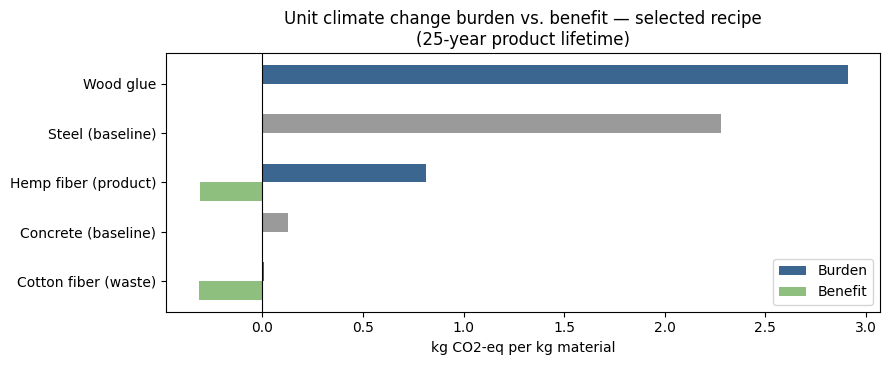

,label,is_baseline,burden,benefit
0,Cotton fiber (waste),False,0.007535,-0.316445
1,Concrete (baseline),True,0.127571,0.000000
2,Hemp fiber (product),False,0.814968,-0.310507
3,Steel (baseline),True,2.282167,0.000000
4,Wood glue,False,2.908964,0.000000


In [59]:
example_recipe = [
    RecipeItem("Hemp fiber", quantity_kg=0.6, allocation_type="product"),
    RecipeItem("Cotton fiber", quantity_kg=0.2, allocation_type="waste"),
    RecipeItem("Wood glue", quantity_kg=0.2),  # binding material, no allocation
]
LIFETIME_YR = 25

burdens, benefit = compute_recipe_impacts(example_recipe, lifetime_yr=LIFETIME_YR)

print("Total burdens (selected categories):")
for cat in ["climate change", "land use", "eutrophication: terrestrial"]:
    print(f"  {cat:<30s} {burdens[cat]:.4e}")

print(f"\nTotal climate-change benefit: {benefit:.4e} kg CO2-eq")
print(f"Net climate change (burden + benefit): {burdens['climate change'] + benefit:.4e} kg CO2-eq")

df_benchmark = plot_recipe_benchmark(example_recipe, lifetime_yr=LIFETIME_YR)
df_benchmark